In [69]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("../data/reviews.csv")
df.head()

,review,sentiment
0,"This desk lamp has both good and bad points, o...",Neutral
1,"The smartwatch exceeded my expectations, aweso...",Positive
2,"Really top-notch bluetooth speaker, exactly as...",Positive
3,Shipping took a while but the laptop backpack ...,Positive
4,"FAST SHIPPING, HOWEVER THE SMARTWATCH ITSELF I...",Negative


In [70]:
df.shape

(1504, 2)

In [71]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [72]:
df.isnull().sum()

review       2
sentiment    0
dtype: int64

In [73]:
df[df['review'].isna()]

,review,sentiment
10,NaN,Positive
20,NaN,Negative


In [74]:
df=df.dropna(subset=['review']).reset_index(drop=True)

In [75]:
df.shape

(1502, 2)

In [76]:
df.duplicated().sum()

np.int64(43)

In [77]:
df[df.duplicated("review",keep=False)].sort_values("review")          

,review,sentiment
219,Absolutely love this office chair. It's durabl...,Neutral
1272,Absolutely love this office chair. It's durabl...,Positive
1259,An reasonable phone case that does the basic j...,Neutral
1285,An reasonable phone case that does the basic j...,Neutral
696,"DO NOT WASTE YOUR MONEY ON THIS COFFEE MAKER, ...",Negative
...,...,...
1415,"This office chair is decent. Not bad, not grea...",Neutral
1145,"This phone case has both good and bad points, ...",Neutral
1398,"This phone case has both good and bad points, ...",Neutral
1070,"the wireless charger isn't bad, isn't great ei...",Neutral


In [78]:
df.groupby("review")["sentiment"].nunique().value_counts()

sentiment
1    1453
2       3
Name: count, dtype: int64

In [79]:
conflicts=df.groupby("review")["sentiment"].nunique()
conflicts=conflicts[conflicts>1]
df[df["review"].isin(conflicts.index)].sort_values("review")

,review,sentiment
219,Absolutely love this office chair. It's durabl...,Neutral
1272,Absolutely love this office chair. It's durabl...,Positive
107,Shipping took a while but the wireless earbuds...,Positive
872,Shipping took a while but the wireless earbuds...,Negative
206,"The hair dryer works as expected, adequate for...",Neutral
340,"The hair dryer works as expected, adequate for...",Negative


In [80]:
conflicting_reviews=df.groupby("review")["sentiment"].nunique()
conflicting_reviews=conflicting_reviews[conflicting_reviews>1].index
df=df[~df["review"].isin(conflicting_reviews)].reset_index(drop=True)
df.shape

(1496, 2)

In [81]:
df.duplicated("review").sum()

np.int64(43)

In [82]:
df[df.duplicated("review",keep=False)].groupby("review")["sentiment"].nunique().value_counts()

sentiment
1    43
Name: count, dtype: int64

In [83]:
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

In [84]:
df.shape

(1453, 2)

In [85]:
df["sentiment"].value_counts()

sentiment
Negative    485
Neutral     484
Positive    484
Name: count, dtype: int64

In [86]:
df.dtypes

review       str
sentiment    str
dtype: object

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     1453 non-null   str  
 1   sentiment  1453 non-null   str  
dtypes: str(2)
memory usage: 161.9 KB


In [88]:
df.to_csv("../data/clean_reviews.csv", index=False)

Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

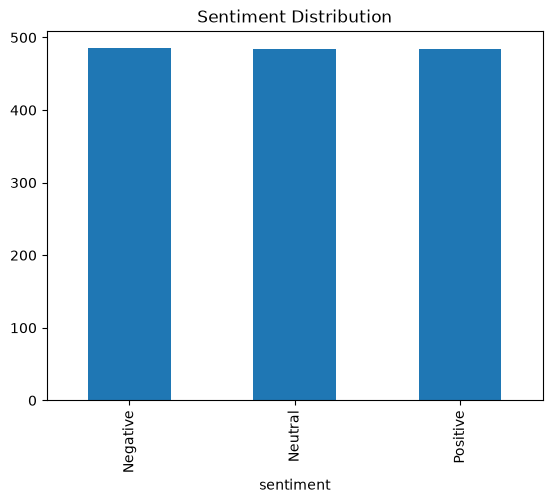

In [68]:
df["sentiment"].value_counts().plot(kind="bar", title="Sentiment Distribution")